<a href="https://colab.research.google.com/github/najamoe/MLExam/blob/main/MLExamNajaMoe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Installs

In [ ]:
pip install ucimlrepo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier
)

# Load

In [ ]:
adult = fetch_ucirepo(id=2)

X = adult.data.features
y = adult.data.targets

# Creating dataframe

In [ ]:
df = X.copy()

df["income"] = y

# Inspecting dataframe

In [ ]:
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


# Missing values

In [ ]:
df.isnull().sum()

,0
age,0
workclass,963
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,966
relationship,0
race,0
sex,0


In [ ]:
# Viewing the columns
pd.get_dummies(df)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_?,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,income_<=50K,income_<=50K.,income_>50K,income_>50K.
0,39,77516,13,2174,0,40,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False
1,50,83311,13,0,0,13,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False
2,38,215646,9,0,0,40,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False
3,53,234721,7,0,0,40,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False
4,28,338409,13,0,0,40,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,215419,13,0,0,36,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
48838,64,321403,9,0,0,40,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
48839,38,374983,13,0,0,50,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
48840,44,83891,13,5455,0,40,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False


In [ ]:
# Cleaning income column
df["income"] = df["income"].str.replace(
    ".",
    "",
    regex=False
)

df["income"] = df["income"].str.strip()

In [ ]:
# Removing missing values
df = df.dropna()

# One hot encoding

In [ ]:

df = pd.get_dummies(df, drop_first=True)

# Creating Features and Labels

In [ ]:
X = df.drop("income_>50K", axis=1)

y = df["income_>50K"]

In [ ]:
# Verifying columns
print(df.columns)

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week', 'workclass_Federal-gov', 'workclass_Local-gov',
       'workclass_Never-worked', 'workclass_Private',
       ...
       'native-country_Puerto-Rico', 'native-country_Scotland',
       'native-country_South', 'native-country_Taiwan',
       'native-country_Thailand', 'native-country_Trinadad&Tobago',
       'native-country_United-States', 'native-country_Vietnam',
       'native-country_Yugoslavia', 'income_>50K'],
      dtype='object', length=101)


# Train/Test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#Random forest Model

Random Forest is an ensemble learning method that combines many decision trees to improve prediction accuracy and reduce overfitting.



In [ ]:
rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

# Random forest predicitions
rf_predictions = rf_model.predict(X_test)

In [ ]:
# Random forest evaluation
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print("Random Forest Accuracy:")
print(rf_accuracy)

Random Forest Accuracy:
0.847979002624672


In [ ]:
# Confusion matrix
print(confusion_matrix(
  y_test,
  rf_predictions
))

[[6674  496]
 [ 952 1403]]


In [ ]:
# Classification report
print(classification_report(
    y_test,
    rf_predictions
))

              precision    recall  f1-score   support

       False       0.88      0.93      0.90      7170
        True       0.74      0.60      0.66      2355

    accuracy                           0.85      9525
   macro avg       0.81      0.76      0.78      9525
weighted avg       0.84      0.85      0.84      9525



# Hyperparameter tuning

In [ ]:
# param grid
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 20],
    "min_samples_split": [2, 5, 10]
}

GridSearchCV is used to test multiple hyperparameter combinations and find the best performing model.

In [ ]:
# Grid search
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42
    ),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 20],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [ ]:
# Best hyperparameters
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 200}


In [ ]:
# Best random forest model
best_rf_model = grid_search.best_estimator_

# Evaluating tuned random forest

In [ ]:
best_rf_predictions = best_rf_model.predict(X_test)

best_rf_accuracy = accuracy_score(
    y_test,
    best_rf_predictions
)

print("Tuned Random Forest Accuracy:")
print(best_rf_accuracy)

Tuned Random Forest Accuracy:
0.8600524934383202


In [ ]:
# Confusion matrix
print(confusion_matrix(
    y_test,
    best_rf_predictions
))

[[6828  342]
 [ 991 1364]]


In [ ]:
# Classification report
print(classification_report(
    y_test,
    best_rf_predictions
))

              precision    recall  f1-score   support

       False       0.87      0.95      0.91      7170
        True       0.80      0.58      0.67      2355

    accuracy                           0.86      9525
   macro avg       0.84      0.77      0.79      9525
weighted avg       0.86      0.86      0.85      9525



# Baseline for gradient boosting model

In [ ]:
gb_model = HistGradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

HistGradientBoostingClassifier(random_state=42)

In [ ]:
# Gradient boosting predictions
gb_predictions = gb_model.predict(X_test)

In [ ]:
# Gradient boosting evaluation
gb_accuracy = accuracy_score(
    y_test,
    gb_predictions
)

print("Gradient Boosting Accuracy:")
print(gb_accuracy)

Gradient Boosting Accuracy:
0.8685564304461942


In [ ]:
# Confusion matrix
print(confusion_matrix(
    y_test,
    gb_predictions
))

[[6786  384]
 [ 868 1487]]


In [ ]:
# Classification report
print(classification_report(
    y_test,
    gb_predictions
))

              precision    recall  f1-score   support

       False       0.89      0.95      0.92      7170
        True       0.79      0.63      0.70      2355

    accuracy                           0.87      9525
   macro avg       0.84      0.79      0.81      9525
weighted avg       0.86      0.87      0.86      9525



# Gradient boosting hyperparameter tuning

In [ ]:
gb_param_grid = {
    "learning_rate": [0.01, 0.1],
    "max_iter": [100, 200],
    "max_depth": [5, 10]
}

In [ ]:
# Grid search for gradient boosting
gb_grid_search = GridSearchCV(
    estimator=HistGradientBoostingClassifier(
        random_state=42
    ),
    param_grid=gb_param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

gb_grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=HistGradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [5, 10],
                         'max_iter': [100, 200]},
             scoring='accuracy')

In [ ]:
# Best gradient boosting parameters
print("Best Gradient Boosting Parameters:")
print(gb_grid_search.best_params_)

Best Gradient Boosting Parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'max_iter': 200}


In [ ]:
# Best gradient boosting model
best_gb_model = gb_grid_search.best_estimator_

In [ ]:
# Evaluating tuned gradient boosting
best_gb_predictions = best_gb_model.predict(X_test)

best_gb_accuracy = accuracy_score(
    y_test,
    best_gb_predictions
)

print("Tuned Gradient Boosting Accuracy:")
print(best_gb_accuracy)

Tuned Gradient Boosting Accuracy:
0.8685564304461942


In [ ]:
# Confusion matrix
print(confusion_matrix(
    y_test,
    best_gb_predictions
))

[[6794  376]
 [ 876 1479]]


In [ ]:
# Classification report
print(classification_report(
    y_test,
    best_gb_predictions
))

              precision    recall  f1-score   support

       False       0.89      0.95      0.92      7170
        True       0.80      0.63      0.70      2355

    accuracy                           0.87      9525
   macro avg       0.84      0.79      0.81      9525
weighted avg       0.86      0.87      0.86      9525



# Comparing models

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Tuned Random Forest",
        "Gradient Boosting",
        "Tuned Gradient Boosting"
    ],
    "Accuracy": [
        rf_accuracy,
        best_rf_accuracy,
        gb_accuracy,
        best_gb_accuracy
    ]
})

print(results)

                     Model  Accuracy
0            Random Forest  0.847979
1      Tuned Random Forest  0.860052
2        Gradient Boosting  0.868556
3  Tuned Gradient Boosting  0.868556


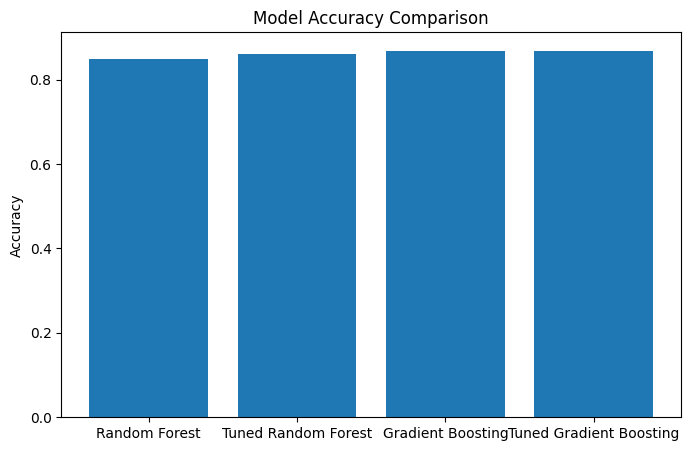

In [ ]:
# Visual model comparison
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.show()

# Feature importance
Feature importance shows which features contributed most to the model's predictions.

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

                              Feature  Importance
3                        capital-gain    0.157214
30  marital-status_Married-civ-spouse    0.140754
2                       education-num    0.101860
0                                 age    0.083871
5                      hours-per-week    0.054163
32       marital-status_Never-married    0.053180
4                        capital-loss    0.045129
1                              fnlwgt    0.036380
49         relationship_Not-in-family    0.031870
38         occupation_Exec-managerial    0.029533


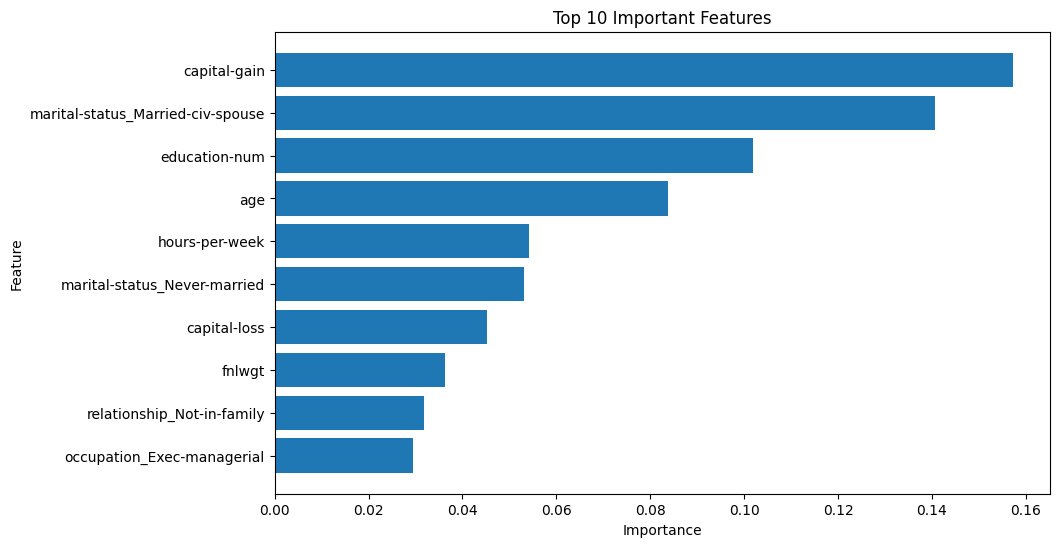

In [ ]:
# feature importance plottet
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

# Conclusion

The project compared Random Forest and Gradient Boosting on the Adult Income dataset.

Hyperparameter tuning improved the Random Forest model performance from approximately 84.8% to 86.0%.

Gradient Boosting achieved the highest accuracy overall.

The project demonstrated:
- data preprocessing
- categorical encoding
- ensemble learning
- hyperparameter tuning
- model evaluation